In [26]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2 
from pathlib import Path
import pandas as pd

Imagens encontradas! 5
--------------------------------------------------
Processando:  queimada1.jpg


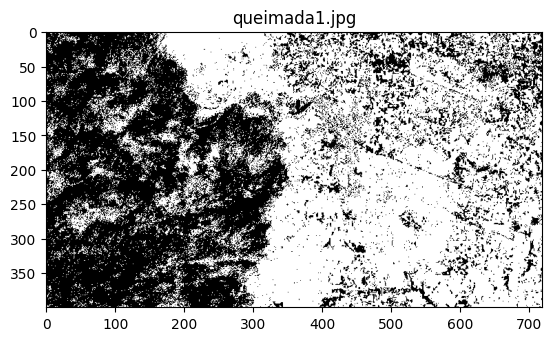

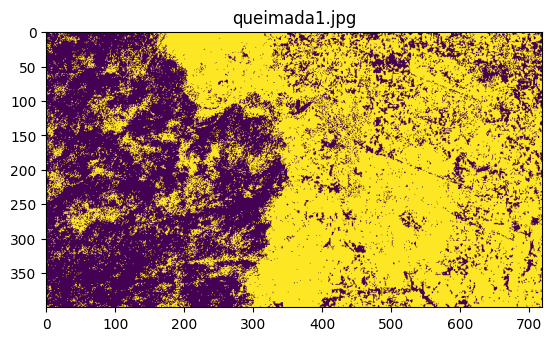

Pixels detectados:  165443
Tamanho  (400, 720, 3)
Área detectada: 57.45 %
Salvo: ..\imagens\queimadas marcadas\queimada1.jpg
--------------------------------------------------------------------------------
Processando:  queimada2.jpg


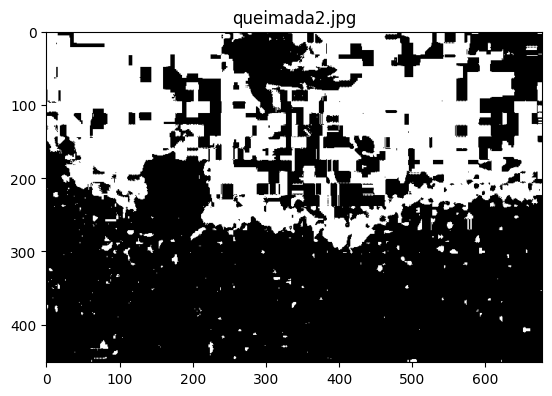

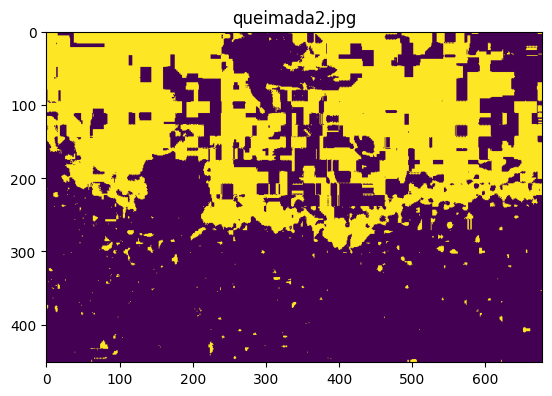

Pixels detectados:  112158
Tamanho  (452, 678, 3)
Área detectada: 36.6 %
Salvo: ..\imagens\queimadas marcadas\queimada2.jpg
--------------------------------------------------------------------------------
Processando:  queimada3.jpg


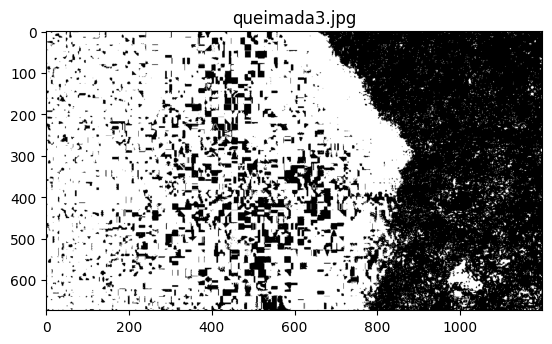

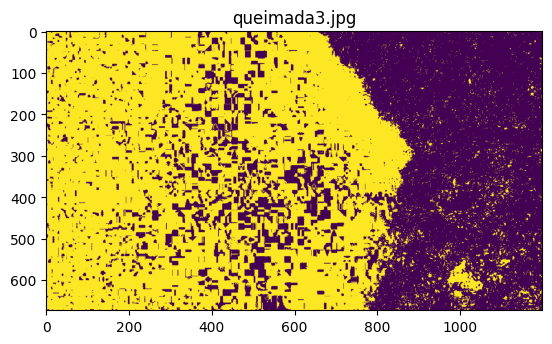

Pixels detectados:  461274
Tamanho  (674, 1199, 3)
Área detectada: 57.08 %
Salvo: ..\imagens\queimadas marcadas\queimada3.jpg
--------------------------------------------------------------------------------
Processando:  queimada4.jpg


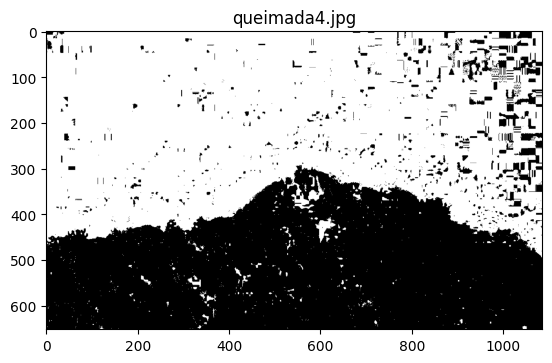

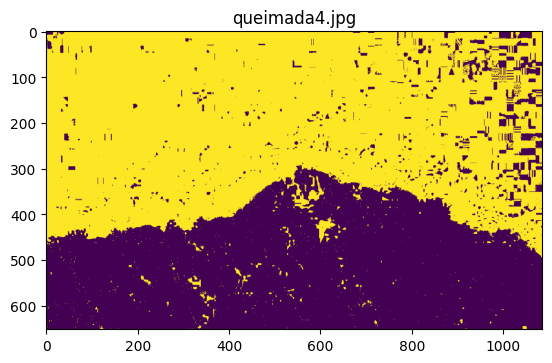

Pixels detectados:  409549
Tamanho  (652, 1086, 3)
Área detectada: 57.84 %
Salvo: ..\imagens\queimadas marcadas\queimada4.jpg
--------------------------------------------------------------------------------
Processando:  queimada6.jpg


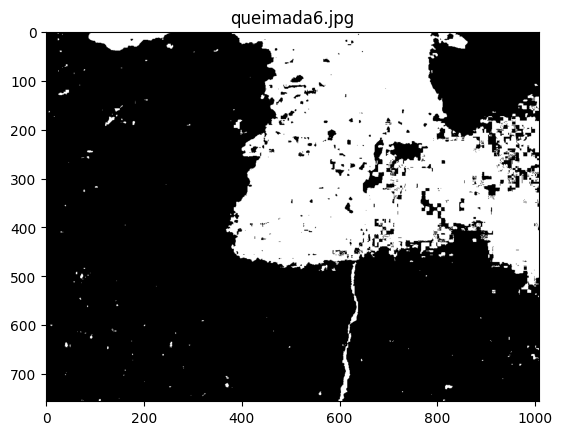

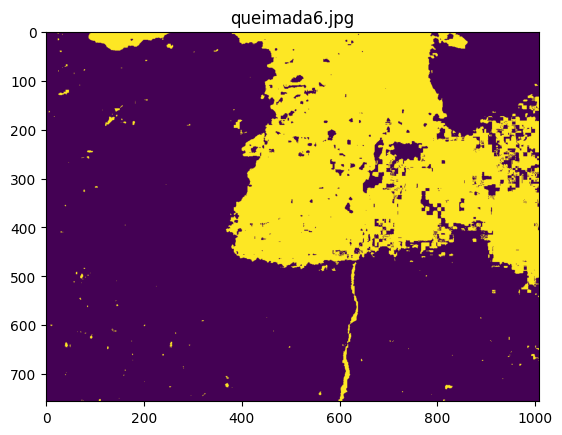

Pixels detectados:  218139
Tamanho  (756, 1008, 3)
Área detectada: 28.63 %
Salvo: ..\imagens\queimadas marcadas\queimada6.jpg
--------------------------------------------------------------------------------
          Imagem  Pixels queimados  Pixels totais  Área queimada (%)
0  queimada1.jpg            165443         288000              57.45
1  queimada2.jpg            112158         306456              36.60
2  queimada3.jpg            461274         808126              57.08
3  queimada4.jpg            409549         708072              57.84
4  queimada6.jpg            218139         762048              28.63


In [27]:
pasta_img = Path('../imagens/queimadas')
pasta_resultado = Path('../imagens/queimadas marcadas')

#procura as imagens 
imagens = list(pasta_img.glob("*.jpg"))
imagens += list(pasta_img.glob("*.jpeg"))
imagens += list(pasta_img.glob("*.png"))

print('Imagens encontradas!', len(imagens))
print('-' * 50)

resultados = [ ]

#codigo para fazer calculo da area queimada automatico 
for caminho_imagem in imagens:

    print('Processando: ', caminho_imagem.name)
    #abre as imagens uma por uma 
    imagem = Image.open(caminho_imagem)

    #transformar todos os pixels em matrizes com valores RGB
    imagem_array = np.array(imagem)

    #separando canal de cores
    vermelho = imagem_array[:,:,0]
    verde = imagem_array[:,:,1]
    azul = imagem_array[:,:,2]

    #Índice de Excesso de Verde
    exg = 2 * verde.astype(float) - vermelho.astype(float) - azul.astype(float)

    #abrindo imagens em cinza
    #para cada pixel, verificar se o valor do ExG é menor que zero, se o pixel não tem verde predominante ele fica negativo e calcula automaticamente como area afetada
    mascara_exg = exg < 0  
    plt.imshow(mascara_exg, cmap='gray') 
    plt.title(caminho_imagem.name)
    plt.show()

    #abrindo imagens com cor
    mascara_exg = exg < 0 #para cada pixel, verificar se o valor do ExG é menor que zero
    plt.imshow(mascara_exg)
    plt.title(caminho_imagem.name)
    plt.show()

    print('Pixels detectados: ', mascara_exg.sum())
    print('Tamanho ', imagem_array.shape)
    total_pixels = mascara_exg.size #quantidade total de pixels da imagem (refatorado)
    pixels_queimados = mascara_exg.sum() #conta quantos pixels foram classificados pela máscara (pixels queimados)

    porcentagem = (pixels_queimados / total_pixels) * 100 #porcentagem da area de queimadas 

    print("Área detectada:", round(porcentagem, 2), "%")

    #pintando area queimada de vermelho 
    resultado_array = imagem_array.copy()
    resultado_array[mascara_exg] = [255, 0, 0]
    area_vermelha = cv2.addWeighted(imagem_array, 0.7, resultado_array, 0.3, 0)

    resultado = Image.fromarray(area_vermelha)

    #salvando a imagem marcada
    nome_saida = pasta_resultado / caminho_imagem.name
    resultado.save(nome_saida)

    print("Salvo:", nome_saida)
    print('-' * 80)

    resultados.append({
        'Imagem': caminho_imagem.name,
        'Pixels queimados': pixels_queimados,
        'Pixels totais': total_pixels,
        'Área queimada (%)': round(porcentagem, 2)
    })

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

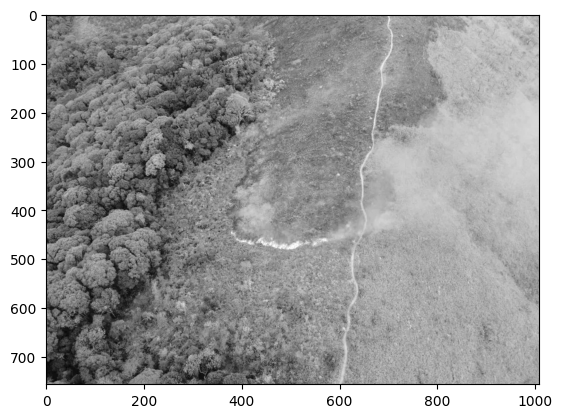

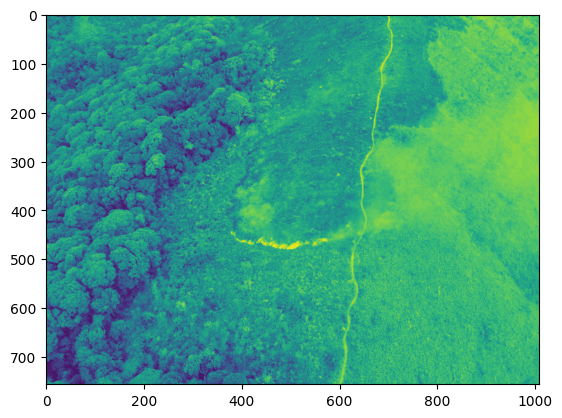

In [30]:
#isolando o vermelho
plt.imshow(vermelho, cmap='gray') #prepara a img 
plt.show() #mostra a img 
plt.imshow(vermelho) #prepara a img 
plt.show() #mostra a img 

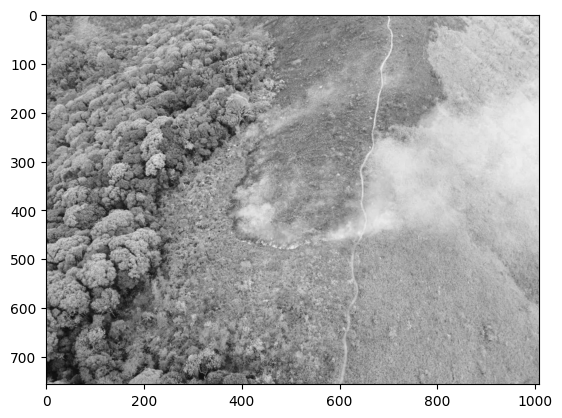

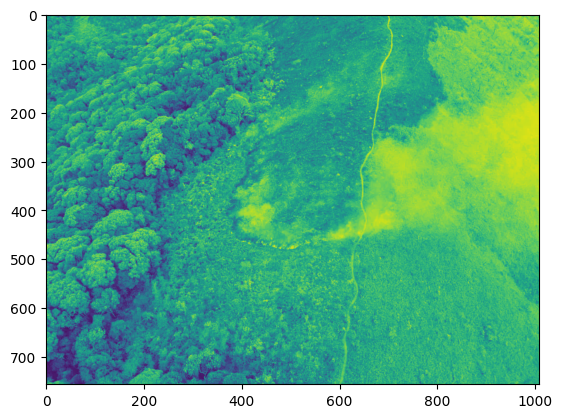

In [31]:
#isolando o verde
plt.imshow(verde, cmap='gray') #prepara a img 
plt.show() #mostra a img 
plt.imshow(verde) #prepara a img 
plt.show() #mostra a img 

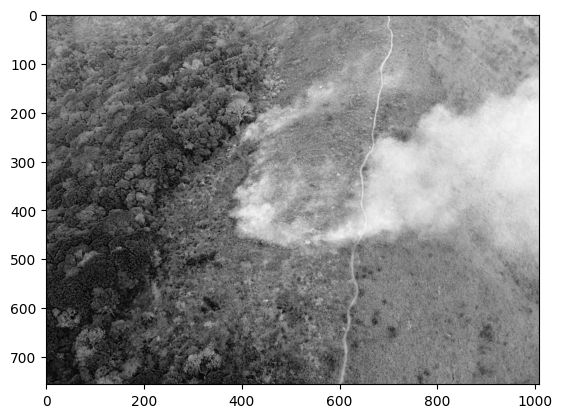

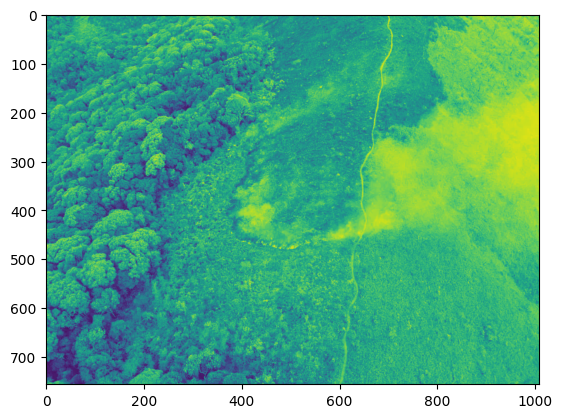

In [32]:
#isolando o azul
plt.imshow(azul, cmap='gray') #prepara a img 
plt.show() #mostra a img 
plt.imshow(verde) #prepara a img 
plt.show() #mostra a img 